# Bayesian Logistic Regression Models

## Overview: Create a few BLR models for each umpire with different feature subsets and compare the posterior predictives


---
## Project Workflow:
1. **Install and Import Necessary Libraries**
2. **Create Model Feature Sets**
3. **Create Models**
4. **Sample Posterior & Save Context**
5. **Compare Models**


# Step 1: Install and Import Necessary Libraries


In [28]:
import pymc as pm
import pandas as pd
import arviz as az
import matplotlib.pyplot as plt
import os
import json
import numpy as np

# Step 2: Create Model Feature Sets

In [29]:
# Define priors using a dictionary of {feature_name: prior_mean}
# Model 1: mixed features
mixed = {
    'zone': 1,
    'plate_x': -1, 'plate_z': -1, 'pitch_location': -2,
    'sz_top': 1, 'sz_bot': 1
}

# Model 2: physical features
phys_feats = {
    'sz_top': 1, 
    'sz_bot': 1,
    'plate_x': -1,
    'plate_z': -1,
    'pitch_location': -2,
    'vx0': 0,
    'vy0': 0,
}

#  Final model
refined = {
    'pfx_x': 1,
    'plate_x': -1,
    'plate_z': -1,
    'pitch_location': -2,
    'sz_top': 1,
    'sz_bot': 1,
    'stand_R': 1, 
    'p_throws_R': 1,
    'zone': -1
}
# TODO: add model 4 and proper mu values

feature_sets = {
    "1_all_feats": mixed, #TODO: uncomment
    "2_phys_feats": phys_feats,
    "3_refined": refined
}

umpire_files = ["Umpire_1", "Umpire_2", "Umpire_3"]

# to store results locally
models = {}
traces = {}
summaries_priors = {}
summaries_posterior = {}

# Step 3: Create Models

In [30]:
for umpire_file in umpire_files:
    for model_name, features in feature_sets.items():
        data = pd.read_csv(f"data/cleaned/{umpire_file}_cleaned.csv") 
        coords = {'n_obs': range(len(data))}

        with pm.Model(coords=coords) as model:
            print(f"... Starting loop for {model_name}")
            # Intercept
            intercept = pm.Normal('intercept', mu=0, sigma=2)

            # Create priors and store references
            betas = {}
            for name, mu in features.items():
                betas[name] = pm.Normal(f'beta_{name}', mu=mu, sigma=2)

            # Compute logits using vectorized sum
            logits = intercept + sum(betas[name] * data[name] for name in features)

            # Logistic transformation
            p = pm.Deterministic('p', pm.math.sigmoid(logits))

            # Bernoulli likelihood
            y = pm.Bernoulli('y', p=p, observed=data['error_in_decision'])

            # Prior predictive
            prior_pred = pm.sample_prior_predictive(samples=100) # TODO: switch back to 500 samples

            # see what kind of data the model believes is likely just from the priors.
            summary = az.summary(prior_pred, hdi_prob=0.95)
            beta_values = summary.loc[summary.index.str.startswith("beta_")]

            models[model_name] = model
            summaries_priors[model_name] = beta_values
            
            # Save prior definitions for later reference/rebuild
            with open(f"data/rebuild/{umpire_file}_{model_name}_priors.json", "w") as f:
                json.dump(features, f)

Sampling: [beta_pitch_location, beta_plate_x, beta_plate_z, beta_sz_bot, beta_sz_top, beta_zone, intercept, y]


... Starting loop for 1_all_feats


arviz - WARNING - Shape validation failed: input_shape: (1, 100), minimum_shape: (chains=2, draws=4)


KeyboardInterrupt: 

## Visualizations 
not needed for calculations below. Just a sanity check of spread of priors, data actually in data set.

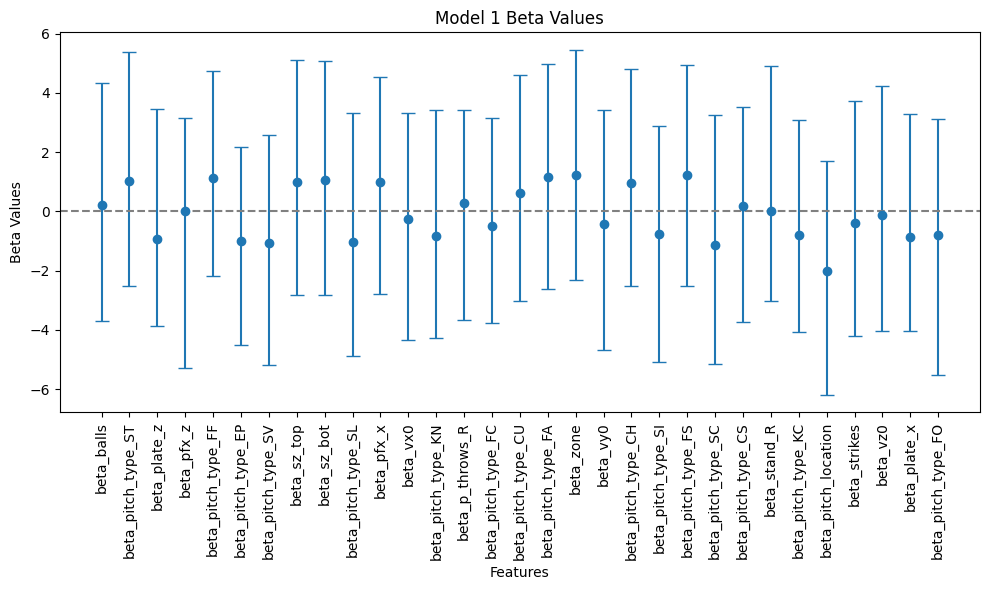

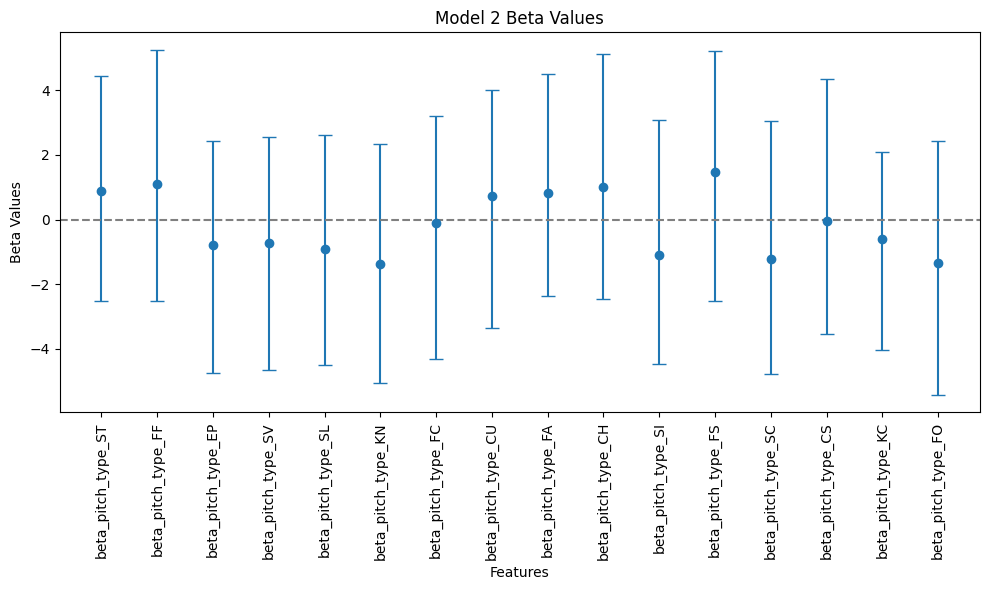

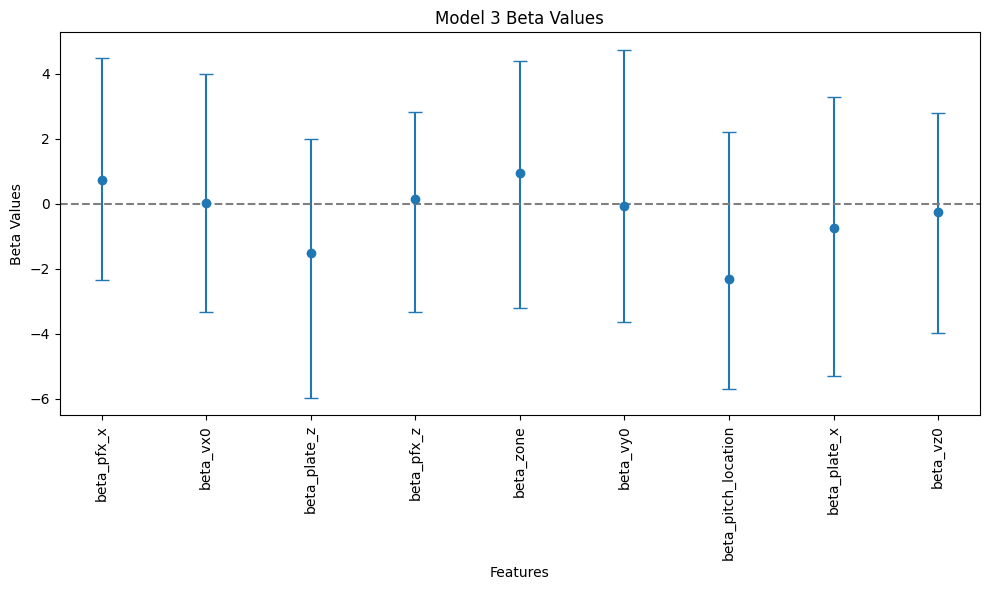

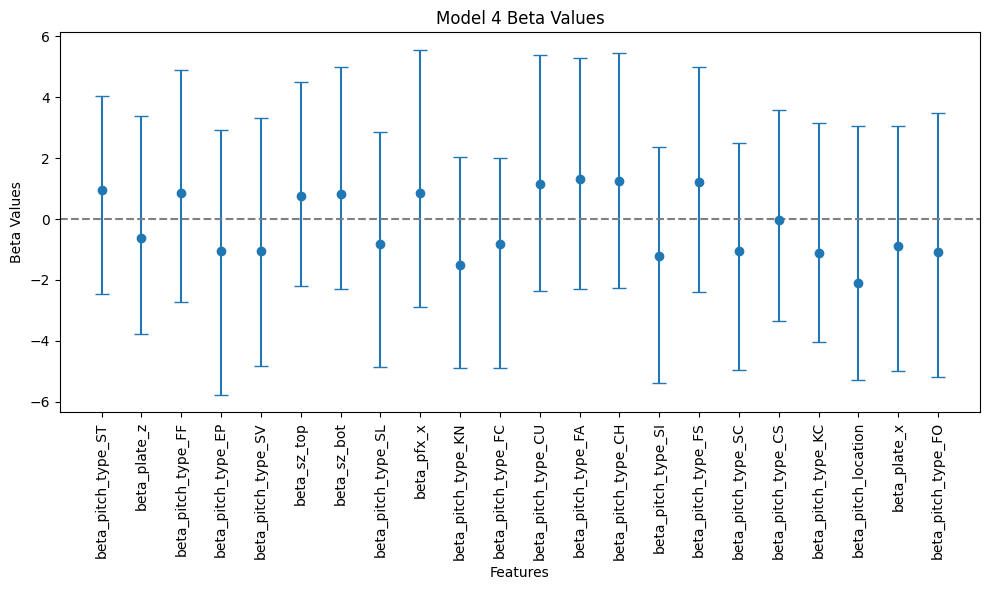

In [ ]:
for ump in umpire_files.items():
    log_path = f"data/rebuild/{ump}_model_prior_summaries.txt"
    open(log_path, "w").close() # Clear previous logs

    with open(log_path, "a") as log_file:
        for index, (name, model) in enumerate(models.items()):
                print(f"\n\n\n---------- Printing {name} Summary ----------", file=log_file)
                print(summaries_priors[name], file=log_file)
            
                plt.figure(figsize=(10, 6))
                plt.errorbar(summaries_priors[name].index, summaries_priors[name]['mean'],
                            yerr=[summaries_priors[name]['mean'] - summaries_priors[name]['hdi_2.5%'], summaries_priors[name]['hdi_97.5%'] - summaries_priors[name]['mean']],
                            fmt='o', capsize=5)
                plt.axhline(0, color='gray', linestyle='--')
                plt.xlabel('Features')
                plt.ylabel('Beta Values')
                plt.title(f'{ump} Model {index + 1} Beta Values')
                plt.xticks(rotation=90)
                plt.tight_layout()
                plt.show()

# Step 4: Sample Posterior & Save Context

In [31]:
def posterior_plot(data, trace, features, ump_file, model_name):
    X = data[features].values
    y_true = data['error_in_decision'].values

    intercept_samples = trace.posterior["β_0"].stack(sample=("chain", "draw")).values
    beta_samples = trace.posterior["β"].stack(sample=("chain", "draw")).values
    pred_probs = 1/ (1+np.exp(-(intercept_samples[:, None] + np.dot(beta_samples.T, X.T))))
    y_pred_mean = pred_probs.mean(axis=0)

    plt.figure(figsize=(8,4))
    plt.hist(y_pred_mean[y_true == 1], bins = 10, alpha = 0.6, label="Incorrect Calls", color='limegreen')
    plt.hist(y_pred_mean[y_true == 0], bins = 10, alpha = 0.6, label="Correct Calls", color='violet')
    plt.xlabel("Predicted Probability of Incorrect Call")
    plt.ylabel("frequency")
    plt.title(f"Model {model_name} {ump_file} Posterior Predictive")
    plt.legend()
    plt.tight_layout()
    plt.show()

In [ ]:
for ump_file in umpire_files:
    for model_name, features in feature_sets.items():
        data = pd.read_csv(f"data/cleaned/{ump_file}_cleaned.csv") 
        for name, mu in features.items():
            X = data[name].values
        y = data['error_in_decision']
        
        with pm.Model() as model:
            # Intercept
            intercept = pm.Normal('intercept', mu=0, sigma=2)

            # Create priors and store references
            betas = {}
            for name, mu in features.items():
                betas[name] = pm.Normal(f'beta_{name}', mu=mu, sigma=2)

            # Compute logits using vectorized sum
            logits = intercept + sum(betas[name] * data[name] for name in features)
            
            theta = pm.Deterministic("theta", pm.math.sigmoid(logits))
            y_obs = pm.Bernoulli("y_obs", p=theta, observed=y)
            
            # Sample
            approx = pm.fit(method="advi", n=20000)
            trace = approx.sample(draws=1000)
            # trace =trace.extend() TODO: fix this line. cannot use az.from_pymc

            az.to_netcdf(trace, f"rdata/rebuild/{ump_file}_{model_name}_traces.nc")
            
    posterior_plot(data, trace, features, ump_file, model_name)

Output()

Finished [100%]: Average Loss = 18,666


AttributeError: module 'arviz' has no attribute 'from_pymc'

If context gets disrupted, add the traces back to local context! Run steps 1,2 again.

In [ ]:
# for model_name in feature_sets:
#     # rebuild models
#     with open(f"data/results/{model_name}_priors.json") as f:
#         priors = json.load(f)
#         model = build_model("3_phys_feats", priors)

#     # rebuild traces
#     trace_path = os.path.join("data/rebuild", f"{model_name}_traces.nc")
    
#     if os.path.exists(trace_path):
#         traces[model_name] = az.from_netcdf(trace_path)
#         print(f"✅ Loaded trace for: {model_name}")
#     else:
#         print(f"❌ Trace file not found: {trace_path}")

In [ ]:
# Compare models
if len(traces) > 1:
    model_compare = az.compare(traces, ic="loo")
    display(model_compare)

In [ ]:
def posterior_calcs(trace, model_name, model):
    summary = az.summary(trace, hdi_prob=0.95)
    summaries_posterior[model_name] = summary

    # Posterior predictive
    ppc = pm.sample_posterior_predictive(trace, model=model)
    trace.extend(ppc)
    
    # Plt posterior
    az.plot_ppc(trace)
    plt.title(f"Posterior Predictive Check: {model_name}")
    plt.show()
    
    # plt forest of betas
    az.plot_forest(trace, var_names=[f"beta_{k}" for k in features.keys()], combined=True)
    plt.title(f"Posterior Forest Plot: {model_name}")
    plt.show()

    # for debugging
        # print(summary.sort_values("mean", ascending=False))